In [1]:
import albumentations as A
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from auxiliary.model_utils import *
from auxiliary.cnn_class import CNN
from auxiliary.pokemon_dataset import PokemonDataset
from auxiliary.numpy_dataset import NumpyDataset

In [2]:
DATA_DIR    = "Pokemon"
IMG_SIZE    = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 50
LR          = 1e-3
N_FOLDS     = 5
RANDOM_SEED = 42
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"
 
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Using device: {DEVICE}")


Using device: cuda


In [3]:
train_transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(64, 64),
    A.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ToTensorV2()
])

In [4]:
# 1. Load the .npy files
x_train = np.load('./Pokemon/X_train.npy')
y_train = np.load('./Pokemon/y_train.npy')

x_val = np.load('./Pokemon/X_val.npy')
y_val = np.load('./Pokemon/y_val.npy')

x_test = np.load('./Pokemon/X_test.npy')
y_test = np.load('./Pokemon/y_test.npy')

le = LabelEncoder()
y_train_idx = le.fit_transform(y_train)  
y_val_idx   = le.transform(y_val)        
y_test_idx  = le.transform(y_test)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 47 classes: ['arbok' 'beedrill' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'ekans'
 'fearow' 'gloom' 'golbat' 'ivysaur' 'jigglypuff' 'kakuna' 'metapod'
 'nidoking' 'nidoqueen' 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino'
 'ninetales' 'oddish' 'paras' 'parasect' 'pidgeot' 'pidgeotto' 'pidgey'
 'pikachu' 'raichu' 'raticate' 'rattata' 'sandshrew' 'sandslash' 'spearow'
 'squirtle' 'venusaur' 'vileplume' 'vulpix' 'wartortle' 'weedle'
 'wigglytuff' 'zubat']


In [5]:
train_loader = DataLoader(NumpyDataset(x_train, y_train_idx, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(NumpyDataset(x_val, y_val_idx, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(NumpyDataset(x_test, y_test_idx, transform=val_transform), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [6]:
# Initialize Model
model = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train),
        "train_acc":  train_correct / len(x_train),
        "val_loss":   val_loss / len(x_val),
        "val_acc":    val_correct / len(x_val)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

Detected flattened size: 8192


/home/viviteto/miniforge3/envs/ml_env/lib/python3.12/site-packages/torch/nn/modules/linear.py:125: UserWarning: Attempting to use hipBLASLt on an unsupported architecture! Overriding blas backend to hipblas (Triggered internally at ../aten/src/ATen/Context.cpp:296.)
  return F.linear(input, self.weight, self.bias)


Epoch 01/50 | Train Loss: 3.5245 Acc: 0.0913 | Val Loss: 2.7671 Acc: 0.2809
Epoch 02/50 | Train Loss: 2.7154 Acc: 0.2540 | Val Loss: 2.2425 Acc: 0.3532
Epoch 03/50 | Train Loss: 2.3561 Acc: 0.3305 | Val Loss: 2.0825 Acc: 0.4277
Epoch 04/50 | Train Loss: 2.1237 Acc: 0.3970 | Val Loss: 1.9516 Acc: 0.4532
Epoch 05/50 | Train Loss: 1.9507 Acc: 0.4442 | Val Loss: 1.8634 Acc: 0.4936
Epoch 06/50 | Train Loss: 1.8045 Acc: 0.4852 | Val Loss: 1.8033 Acc: 0.5000
Epoch 07/50 | Train Loss: 1.6749 Acc: 0.5177 | Val Loss: 1.7820 Acc: 0.5106
Epoch 08/50 | Train Loss: 1.5614 Acc: 0.5478 | Val Loss: 1.7515 Acc: 0.5213
Epoch 09/50 | Train Loss: 1.4586 Acc: 0.5733 | Val Loss: 1.7171 Acc: 0.5362
Epoch 10/50 | Train Loss: 1.3592 Acc: 0.6013 | Val Loss: 1.7078 Acc: 0.5532
Epoch 11/50 | Train Loss: 1.2856 Acc: 0.6179 | Val Loss: 1.6688 Acc: 0.5766
Epoch 12/50 | Train Loss: 1.2020 Acc: 0.6435 | Val Loss: 1.6890 Acc: 0.5809
Epoch 13/50 | Train Loss: 1.1246 Acc: 0.6694 | Val Loss: 1.6923 Acc: 0.5787
Epoch 14/50 

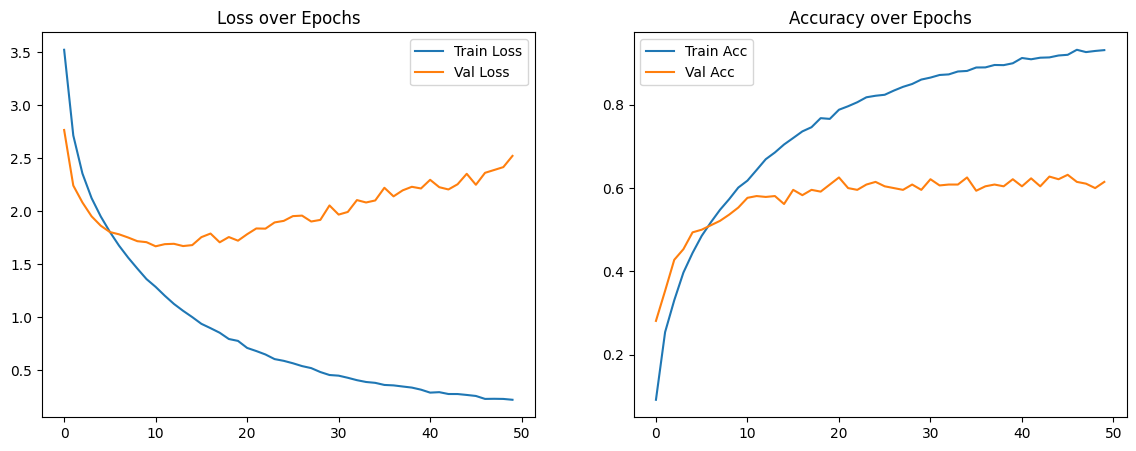

In [7]:
# 1. Plot Training/Validation Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Acc")
ax2.plot(history["val_acc"], label="Val Acc")
ax2.set_title("Accuracy over Epochs")
ax2.legend()

plt.show()

In [8]:
# 2. Final Evaluation on Test Set
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torch.nn.functional as F

model.eval()
all_preds = []
all_labels = []
all_probs = [] # Needed for ROC-AUC

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        
        # Get probabilities using Softmax
        probs = F.softmax(outputs, dim=1)
        
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Precision, Recall, and F1-score
# These are all included in the classification_report
print("--- Detailed Classification Report ---")
# target_names uses the labels from your LabelEncoder
report = classification_report(all_labels, all_preds, target_names=le.classes_)
print(report)

# 2. ROC-AUC Score
# For multi-class, we must specify multi_class='ovr' (One-vs-Rest)
# and 'macro' or 'weighted' averaging.
roc_auc_ovr = roc_auc_score(
    all_labels, 
    all_probs, 
    multi_class='ovr', 
    average='macro'
)

print(f"ROC-AUC Score (One-vs-Rest, Macro): {roc_auc_ovr:.4f}")

--- Detailed Classification Report ---
              precision    recall  f1-score   support

       arbok       0.78      0.70      0.74        10
    beedrill       0.60      0.60      0.60        10
   blastoise       0.80      0.40      0.53        10
   bulbasaur       0.70      0.70      0.70        10
  butterfree       0.80      0.80      0.80        10
    caterpie       0.80      0.40      0.53        10
   charizard       0.67      0.80      0.73        10
  charmander       0.44      0.40      0.42        10
  charmeleon       0.57      0.40      0.47        10
    clefable       0.73      0.80      0.76        10
    clefairy       0.62      0.80      0.70        10
       ekans       0.62      0.80      0.70        10
      fearow       0.62      0.50      0.56        10
       gloom       1.00      0.60      0.75        10
      golbat       0.80      0.80      0.80        10
     ivysaur       1.00      0.70      0.82        10
  jigglypuff       0.69      0.90      0.7

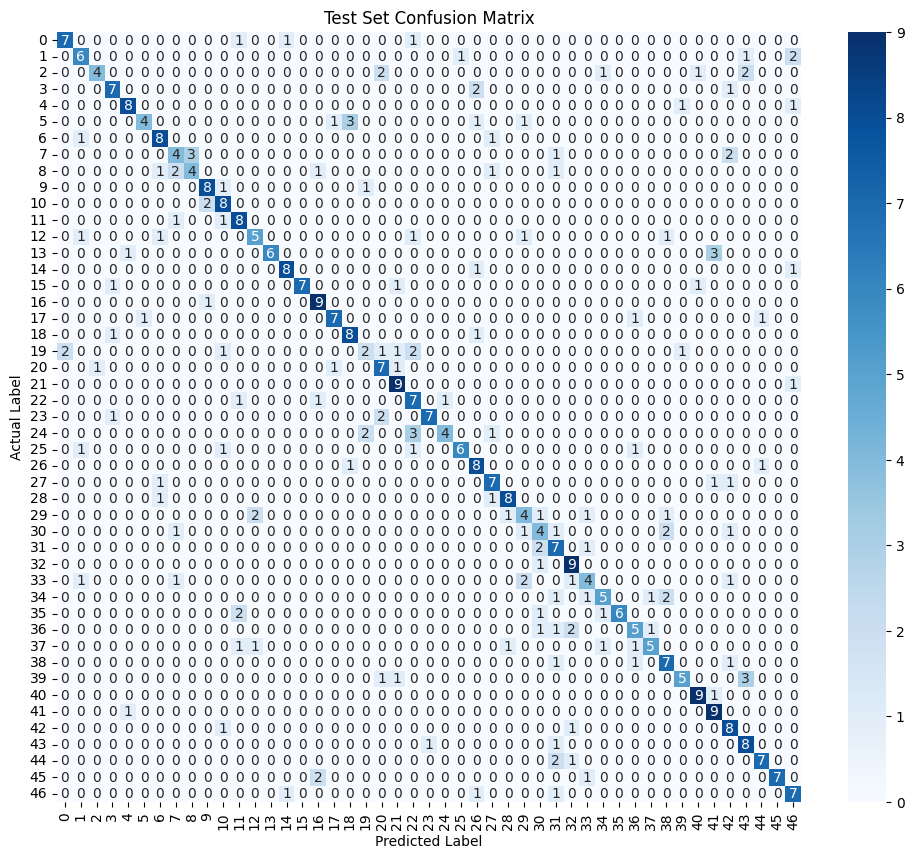

In [9]:
# 3. Confusion Matrix for Test Set
plt.figure(figsize=(12, 10))
sns.heatmap(confusion_matrix(all_labels, all_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

# Run with cleaned images (5 aug)

In [11]:
# 1. Load the .npy files
x_train_5aug = np.load('./Pokemon/X_train_5aug.npy')
y_train_5aug = np.load('./Pokemon/y_train_5aug.npy')

x_val_5aug = np.load('./Pokemon/X_val_5aug.npy')
y_val_5aug = np.load('./Pokemon/y_val_5aug.npy')

x_test_5aug = np.load('./Pokemon/X_test_5aug.npy')
y_test_5aug = np.load('./Pokemon/y_test_5aug.npy')

le = LabelEncoder()
le.fit(y_train_5aug)

y_train_idx_5aug = le.transform(y_train_5aug)  
y_val_idx_5aug   = le.transform(y_val_5aug)        
y_test_idx_5aug  = le.transform(y_test_5aug)

# Save the class names for later plotting
class_names = le.classes_
print(f"Detected {len(class_names)} classes: {class_names}")

Detected 151 classes: ['abra' 'aerodactyl' 'alakazam' 'arbok' 'arcanine' 'articuno' 'beedrill'
 'bellsprout' 'blastoise' 'bulbasaur' 'butterfree' 'caterpie' 'chansey'
 'charizard' 'charmander' 'charmeleon' 'clefable' 'clefairy' 'cloyster'
 'cubone' 'dewgong' 'diglett' 'ditto' 'dodrio' 'doduo' 'dragonair'
 'dragonite' 'dratini' 'drowzee' 'dugtrio' 'eevee' 'ekans' 'electabuzz'
 'electrode' 'exeggcute' 'exeggutor' "farfetch'd" 'fearow' 'flareon'
 'gastly' 'gengar' 'geodude' 'gloom' 'golbat' 'goldeen' 'golduck' 'golem'
 'graveler' 'grimer' 'growlithe' 'gyarados' 'haunter' 'hitmonchan'
 'hitmonlee' 'horsea' 'hypno' 'ivysaur' 'jigglypuff' 'jolteon' 'jynx'
 'kabuto' 'kabutops' 'kadabra' 'kakuna' 'kangaskhan' 'kingler' 'koffing'
 'krabby' 'lapras' 'lickitung' 'machamp' 'machoke' 'machop' 'magikarp'
 'magmar' 'magnemite' 'magneton' 'mankey' 'marowak' 'meowth' 'metapod'
 'mew' 'mewtwo' 'moltres' 'mr mime' 'muk' 'nidoking' 'nidoqueen'
 'nidoran♀' 'nidoran♂' 'nidorina' 'nidorino' 'ninetales' 'oddi

In [12]:
train_loader_5aug = DataLoader(NumpyDataset(x_train_5aug, y_train_5aug, transform=train_transform), 
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader_5aug   = DataLoader(NumpyDataset(x_val_5aug, y_val_idx_5aug), 
                          batch_size=BATCH_SIZE, shuffle=False)
test_loader_5aug  = DataLoader(NumpyDataset(x_test_5aug, y_test_idx_5aug), 
                          batch_size=BATCH_SIZE, shuffle=False)

In [13]:
# Initialize Model
model_5aug = CNN(num_classes=len(le.classes_)).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model_5aug.parameters(), lr=1e-4, weight_decay=0.01)

# Dictionary to store history for plotting
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, EPOCHS + 1):
    model_5aug.train()
    train_loss, train_correct = 0, 0
    
    for images, labels in train_loader_5aug:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model_5aug(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # Validation
    model_5aug.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader_5aug:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model_5aug(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    # Calculate averages
    metrics = {
        "train_loss": train_loss / len(x_train),
        "train_acc":  train_correct / len(x_train),
        "val_loss":   val_loss / len(x_val),
        "val_acc":    val_correct / len(x_val)
    }
    
    for key in history: history[key].append(metrics[key])
    
    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss: {metrics['train_loss']:.4f} Acc: {metrics['train_acc']:.4f} | "
          f"Val Loss: {metrics['val_loss']:.4f} Acc: {metrics['val_acc']:.4f}")

Detected flattened size: 8192


TypeError: new(): invalid data type 'numpy.str_'